In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, make_s_curve

from Autoencoders import ConformalAutoencoder
from helper import load_optimizer_and_scheduler, save_optimizer_and_scheduler
from data import make_half_sphere

from torchvision.datasets import MNIST

random_state = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
class Encoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Encoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),  # (16, 14, 14)
            nn.ReLU(True),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),  # (32, 7, 7)
            nn.ReLU(True),
            nn.Conv2d(32, 64, 7)  # (64, 1, 1)
        )
    
    def forward(self, x):
        return self.fc(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Decoder, self).__init__()
        self.fc = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 7),  # (32, 7, 7)
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),  # (16, 14, 14)
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),  # (1, 28, 28)
            nn.Sigmoid()
        )
    
    def forward(self, z):
        return self.fc(z)

# class Encoder(nn.Module):
#     def __init__(self, input_dim, latent_dim):
#         super(Encoder, self).__init__()
#         self.fc = nn.Sequential(
#             # nn.Flatten(),
#             nn.Linear(28*28, 256),
#             nn.ReLU(True),
#             nn.Linear(256, 128),
#             nn.ReLU(True),
#             nn.Linear(128, 64),
#             nn.ReLU(True),
#             nn.Linear(64, 32)
#         )
    
#     def forward(self, x):
#         return self.fc(x)

# class Decoder(nn.Module):
#     def __init__(self, latent_dim, output_dim):
#         super(Decoder, self).__init__()
#         self.fc = nn.Sequential(
#             nn.Linear(32, 64),
#             nn.ReLU(True),
#             nn.Linear(64, 128),
#             nn.ReLU(True),
#             nn.Linear(128, 256),
#             nn.ReLU(True),
#             nn.Linear(256, 28*28),
#             nn.Sigmoid(),  # For pixel values between 0 and 1
#             # nn.Unflatten(1, (1, 28, 28))
#         )
    
#     def forward(self, z):
#         return self.fc(z)

In [3]:
mnist = MNIST(root='data', train=True, download=True, transform=None)
data, labels = mnist.data, mnist.targets
data = data[labels == 3][:3000]
labels = labels[labels == 3]
data = torch.tensor(data, dtype=torch.float32).to(device)
data = data / 255.0  # Normalize the images to [0, 1]
data = data.view(data.size(0), 1, 28, 28)  # Add channel dimension
mnist_val = MNIST(root='data', train=False, download=True, transform=None)
val_data, val_labels = mnist_val.data, mnist_val.targets
val_data = val_data[val_labels == 3][:1000]
val_labels = val_labels[val_labels == 3]
val_data = torch.tensor(val_data, dtype=torch.float32).to(device)
val_data = val_data / 255.0  # Normalize the images to [0, 1]
val_data = val_data.view(val_data.size(0), 1, 28, 28)  # Add channel dimension

/tmp/ipykernel_4328/3765578967.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data = torch.tensor(data, dtype=torch.float32).to(device)
/tmp/ipykernel_4328/3765578967.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_data = torch.tensor(val_data, dtype=torch.float32).to(device)


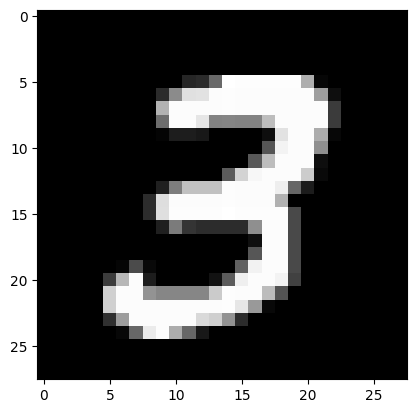

In [4]:
plt.imshow(data[0].view(28, 28).cpu().numpy(), cmap='gray')
plt.show()

In [5]:
# define model parameters
latent_dim = 2
input_dim = data.shape[1]
output_dim = data.shape[1]
batch_size = 64

train_dataloader = torch.utils.data.DataLoader(data, batch_size=batch_size, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=False)

In [11]:
lambda_isos = np.logspace(-3, 3, 15)

In [8]:
from metrics import conformality_angle_loss

In [12]:
num_epochs = 200
# train same model multiple times to average results
num_models = 3

recon_errors = []
regularization_errors = []


for i, lambda_iso in enumerate(lambda_isos):
    recon_error = 0
    regularization = 0
    for j in range(num_models):
        print(f"Training model {j+1}/{num_models} with lambda_iso={lambda_iso:.3f}")
        
        encoder = Encoder(input_dim, latent_dim).to(device)
        decoder = Decoder(latent_dim, output_dim).to(device)
        model = ConformalAutoencoder(encoder, decoder, lambda_conf=lambda_iso).to(device)
        model.conformality_loss = conformality_angle_loss

        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)

        # Train the model
        model.train_model(train_dataloader, val_dataloader, batch_size=batch_size, epochs=num_epochs,
                          optimizer=optimizer, scheduler=scheduler, verbose=True)

        # Save the model and optimizer state
        model_path = f"models/conformal_autoencoder_mnist/lambda_{lambda_iso:.3f}_model_{j+1}.pth"
        torch.save(model.state_dict(), model_path)
        print(f"Model {j+1}/{num_models} with lambda_iso={lambda_iso:.3f} trained and saved.")

        # evaluation
        model.eval()
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)
        
        recon_error += nn.MSELoss()(reconstruction, val_data).item()

        regularization += model.conformality_loss(model.decoder, encoded_data).item()
    
    recon_errors.append(recon_error/ num_models)
    regularization_errors.append(regularization/num_models)
    

Training model 1/3 with lambda_iso=0.001
Epoch [100/200], Loss: 0.00259585, Reconstruction Loss: 0.00259585, Conformal Loss: 0.00000369
Epoch [100/200], Validation Loss: 0.00403182, Reconstruction Loss: 0.00403181, Conformal Loss: 0.00000371
Epoch [200/200], Loss: 0.00185105, Reconstruction Loss: 0.00185105, Conformal Loss: 0.00000470
Epoch [200/200], Validation Loss: 0.00354708, Reconstruction Loss: 0.00354707, Conformal Loss: 0.00000469
Model 1/3 with lambda_iso=0.001 trained and saved.
Training model 2/3 with lambda_iso=0.001
Epoch [100/200], Loss: 0.00209210, Reconstruction Loss: 0.00209209, Conformal Loss: 0.00000888
Epoch [100/200], Validation Loss: 0.00358882, Reconstruction Loss: 0.00358881, Conformal Loss: 0.00000867
Epoch [200/200], Loss: 0.00154616, Reconstruction Loss: 0.00154615, Conformal Loss: 0.00001111
Epoch [200/200], Validation Loss: 0.00338153, Reconstruction Loss: 0.00338152, Conformal Loss: 0.00001102
Model 2/3 with lambda_iso=0.001 trained and saved.
Training mod

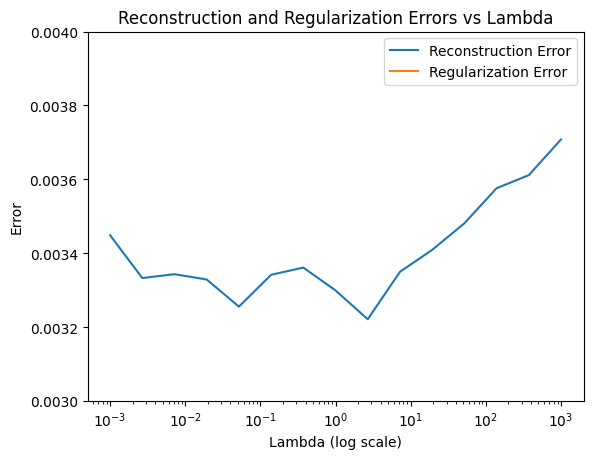

In [17]:
plt.plot(lambda_isos, recon_errors, label='Reconstruction Error')
plt.plot(lambda_isos, regularization_errors, label='Regularization Error')
plt.ylim(0.003, 0.004)
plt.xscale('log')
plt.xlabel('Lambda (log scale)')
plt.ylabel('Error')
plt.title('Reconstruction and Regularization Errors vs Lambda')
plt.legend()
plt.show()

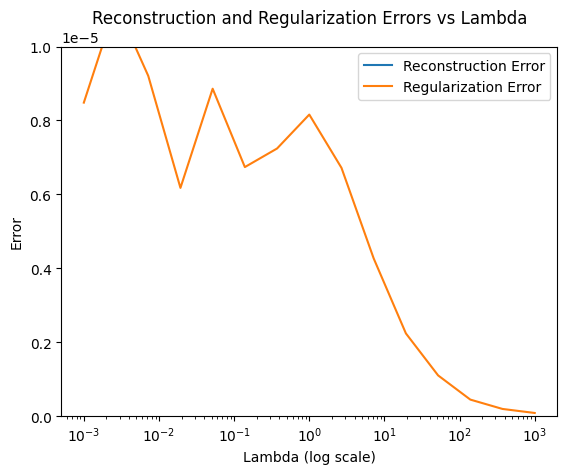

In [20]:
plt.plot(lambda_isos, recon_errors, label='Reconstruction Error')
plt.plot(lambda_isos, regularization_errors, label='Regularization Error')
plt.ylim(0.0, 0.00001)
plt.xscale('log')
plt.xlabel('Lambda (log scale)')
plt.ylabel('Error')
plt.title('Reconstruction and Regularization Errors vs Lambda')
plt.legend()
plt.show()

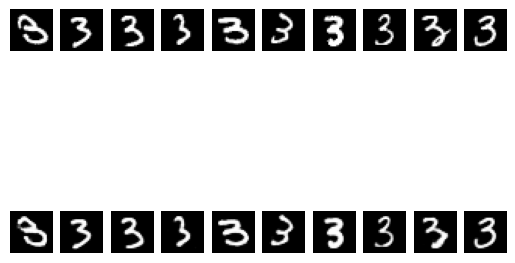

In [39]:
model_path = f"models/conformal_autoencoder_mnist/lambda_{lambda_isos[-1]:.3f}_model_1.pth"
model = ConformalAutoencoder(encoder, decoder, lambda_conf=lambda_isos[-1]).to(device)
model.load_state_dict(torch.load(model_path))

# Visualize the reconstructions
reconstructions = model.decode(model.encode(val_data[:10].to(device)))
for i in range(10):
    plt.subplot(2, 10, i + 1)
    plt.imshow(val_data[i].view(28, 28).cpu().numpy(), cmap='gray')
    plt.axis('off')
    
    plt.subplot(2, 10, i + 11)
    plt.imshow(reconstructions[i].view(28, 28).cpu().detach().numpy(), cmap='gray')
    plt.axis('off')
plt.show()

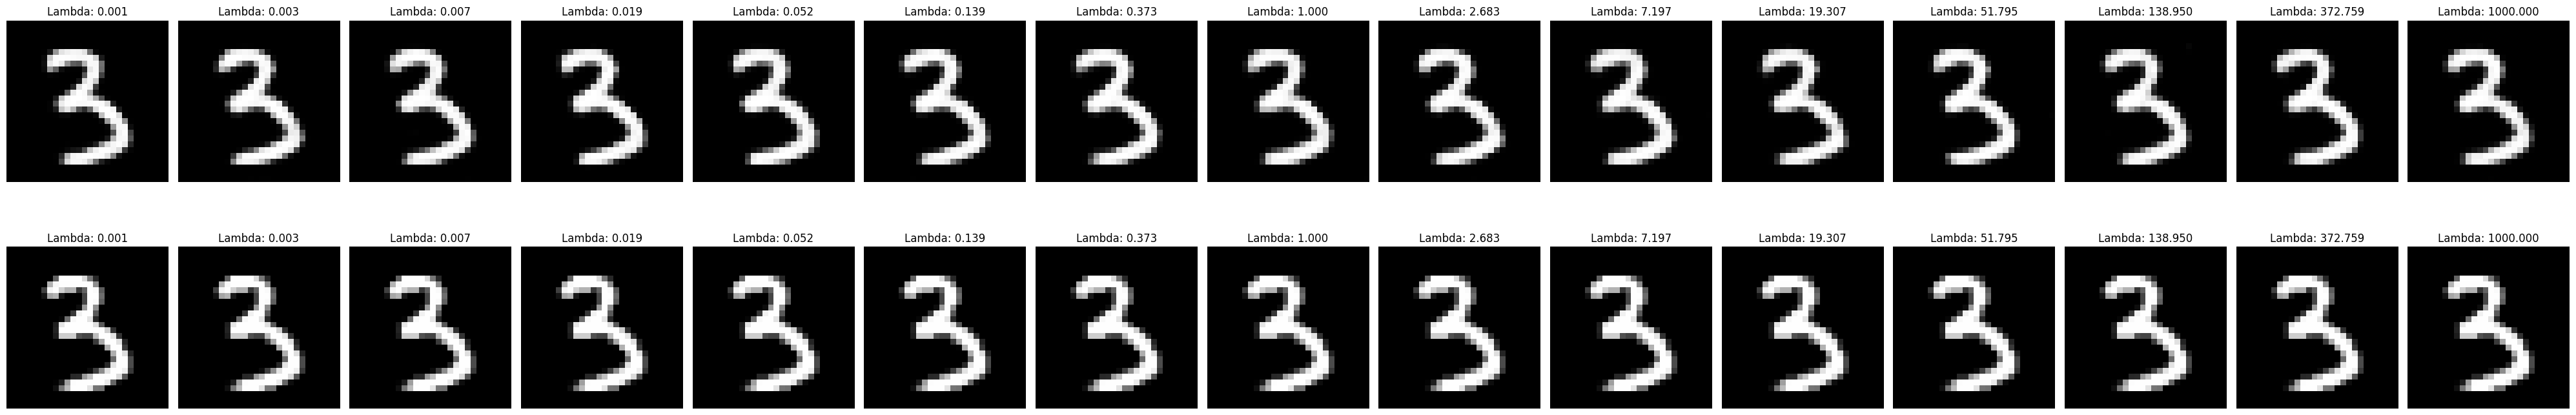

In [32]:
# plot samples and latent space at different lambdas
fig, axs = plt.subplots(2, len(lambda_isos), figsize=(40, 8))
for i, lambda_iso in enumerate(lambda_isos):
    model_path = f"models/conformal_autoencoder_mnist/lambda_{lambda_iso:.3f}_model_1.pth"
    model = ConformalAutoencoder(encoder, decoder, lambda_conf=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))

    # model.eval()
    # with torch.no_grad():
    encoded_data = model.encode(val_data[:10])
    reconstruction = model.decode(encoded_data)

    axs[0, i].imshow(reconstruction[2].view(28, 28).cpu().detach().numpy(), cmap='gray')
    axs[0, i].set_title(f'Lambda: {lambda_iso:.3f}')
    axs[0, i].axis('off')

    axs[1, i].imshow(val_data[2].view(28, 28).cpu().detach().numpy(), cmap='gray')
    axs[1, i].set_title(f'Lambda: {lambda_iso:.3f}')
    axs[1, i].axis('off')
plt.tight_layout()

In [48]:
model_path = f"models/conformal_autoencoder_mnist/lambda_{lambda_isos[-1]:.3f}_model_1.pth"
model = ConformalAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_conf=lambda_isos[-1]).to(device)
model.load_state_dict(torch.load(model_path))

model.eval()
with torch.no_grad():
    encoded_data = model.encode(val_data[:2])
    reconstruction = model.decode(encoded_data)


    for i, z in enumerate(encoded_data):
        z = z.unsqueeze(0)  # Add batch dimension
        y = model.decoder(z)  # Decode to get reconstruction
        y = y.squeeze(0)  # Remove batch dimension

        # Compute the Jacobian J of the decoder at point z
        J = torch.autograd.functional.jacobian(model.decoder, z)[0,:,0,:]
        JtJ = J.transpose(0, 1) @ J
        print(JtJ.size())
        print(encoded_data.size())

    #     eye = torch.eye(JtJ.size(0), device=device)
    #     off_diag_mask = 1.0 - eye
    #     off_diag_elements = JtJ[off_diag_mask.bool()]
    #     loss_matrix = off_diag_elements ** 2

    #     losses.append(loss_matrix.mean().item())
    
    # return np.mean(losses).item()

torch.Size([28, 28, 1, 64, 1, 1])
torch.Size([2, 64, 1, 1])
torch.Size([28, 28, 1, 64, 1, 1])
torch.Size([2, 64, 1, 1])


In [49]:
print(JtJ[:,:,0,0,0,0])

tensor([[ 3.0352e-18,  5.2367e-17,  2.9216e-18,  1.0972e-19,  5.9667e-21,
          9.4161e-21,  1.8404e-21,  2.0862e-22,  4.2756e-22,  2.7949e-20,
          9.5245e-20,  7.9838e-20,  2.1337e-22,  1.2245e-24,  4.7852e-26,
          3.2307e-27, -4.6334e-24, -4.1562e-23, -4.6581e-21, -5.7762e-21,
          9.4572e-24,  4.5367e-25,  2.4468e-23,  3.7554e-24,  8.7466e-24,
          2.5008e-23,  3.5209e-21,  2.7895e-17],
        [ 5.2367e-17,  9.0350e-16,  5.0408e-17,  1.8931e-18,  1.0295e-19,
          1.6246e-19,  3.1753e-20,  3.5994e-21,  7.3769e-21,  4.8221e-19,
          1.6433e-18,  1.3775e-18,  3.6813e-21,  2.1127e-23,  8.2561e-25,
          5.5740e-26, -7.9941e-23, -7.1709e-22, -8.0368e-20, -9.9658e-20,
          1.6317e-22,  7.8273e-24,  4.2215e-22,  6.4794e-23,  1.5091e-22,
          4.3147e-22,  6.0748e-20,  4.8128e-16],
        [ 2.9216e-18,  5.0408e-17,  2.8124e-18,  1.0562e-19,  5.7435e-21,
          9.0639e-21,  1.7716e-21,  2.0082e-22,  4.1157e-22,  2.6903e-20,
          9.16

In [35]:
def diagonality_loss(func, z):
    device = z.device
    losses = []
    for i, z in enumerate(encoded_data):
        z = z.unsqueeze(0)  # Add batch dimension
        y = func(z)  # Decode to get reconstruction
        y = y.squeeze(0)  # Remove batch dimension

        # Compute the Jacobian J of the decoder at point z
        J = torch.autograd.functional.jacobian(func, z)[0,:,0,:]
        JtJ = J.transpose(0, 1) @ J

        eye = torch.eye(JtJ.size(0), device=device)
        off_diag_mask = 1.0 - eye
        off_diag_elements = JtJ[off_diag_mask.bool()]
        loss_matrix = off_diag_elements ** 2

        losses.append(loss_matrix.mean().item())
    
    return np.mean(losses).item()

In [37]:
# measure isometry, scaled isometry, conformity, diagonality, (angle preservation, kl)
from metrics import isometry_loss, scaled_isometry_loss, conformality_loss

for i, lambda_iso in enumerate(lambda_isos):
    print(f"Evaluating model with lambda_iso={lambda_iso:.3f}")
    model_path = f"models/conformal_autoencoder_mnist/lambda_{lambda_iso:.3f}_model_1.pth"
    model = ConformalAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_conf=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))

    model.eval()
    with torch.no_grad():
        encoded_data = model.encode(val_data[:10])
        reconstruction = model.decode(encoded_data)

    isometry = isometry_loss(model.decoder, encoded_data, create_graph=False, augment=False)
    scaled_isometry = scaled_isometry_loss(model.decoder, encoded_data, create_graph=False, augment=False)
    # conformality = conformality_loss(model.decoder, encoded_data)
    diagonality = diagonality_loss(model.decoder, encoded_data)
    print(f"Isometry Loss: {isometry.item()}")
    print(f"Scaled Isometry Loss: {scaled_isometry.item()}")
    # print(f"Conformality Loss: {conformality.item()}")
    print(f"Diagonality Loss: {diagonality}")
    print("-" * 50)

Evaluating model with lambda_iso=0.001
Isometry Loss: 0.9985315203666687
Scaled Isometry Loss: 0.04870064929127693
Diagonality Loss: 1.305166555744099e-26
--------------------------------------------------
Evaluating model with lambda_iso=0.003
Isometry Loss: 0.9976233243942261
Scaled Isometry Loss: 0.045477449893951416
Diagonality Loss: 6.155378930229709e-29
--------------------------------------------------
Evaluating model with lambda_iso=0.007
Isometry Loss: 0.9979907870292664
Scaled Isometry Loss: 0.049913208931684494
Diagonality Loss: 1.2167631827168267e-27
--------------------------------------------------
Evaluating model with lambda_iso=0.019
Isometry Loss: 0.9984010457992554
Scaled Isometry Loss: 0.053543947637081146
Diagonality Loss: 5.195471863699401e-24
--------------------------------------------------
Evaluating model with lambda_iso=0.052
Isometry Loss: 0.9984318614006042
Scaled Isometry Loss: 0.047817811369895935
Diagonality Loss: 2.914123903857391e-24
----------------